In [2]:
import numpy as np
import librosa
from IPython.display import Audio
import matplotlib.pylab as plt
from matplotlib.ticker import FuncFormatter, NullFormatter

In [1]:
WAVE_FILES = ['resources/45047__daveincamas__sleighbells3.wav']

In [4]:
y,sr = librosa.load(WAVE_FILES[0], sr=48000)

Audio(WAVE_FILES[0])

In [3]:
print("Number of samples", len(y))
print("Length", len(y)/sr, "seconds")
print("Max amplitude", np.max(y))

Number of samples 192000
Length 4.0 seconds
Max amplitude 0.43257117


The closer look of the wave shows that the amplitudes are smoothened with having differences peaks.

In [10]:
print("Number of samples", len(c))
print("Length", len(c)/sr, "seconds")
print("Max amplitude", np.max(c))

Number of samples 192000
Length 4.35374149659864 seconds
Max amplitude 20.288598996176795


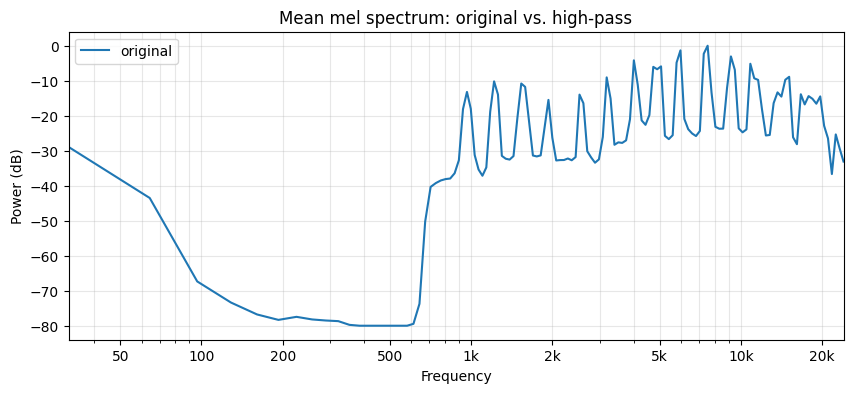

In [5]:
def mean_mel_db(sig, sr, n_mels=128, n_fft=2048, hop_length=512):
    S = librosa.feature.melspectrogram(
        y=sig, sr=sr, n_fft=n_fft, hop_length=hop_length,
        n_mels=n_mels, fmax=sr/2
    )
    return librosa.power_to_db(S.mean(axis=1), ref=np.max)

mel_freqs = librosa.mel_frequencies(n_mels=128, fmax=sr/2)

S_db     = mean_mel_db(y,     sr)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(mel_freqs, S_db,     label='original')
ax.set(xlabel='Frequency', ylabel='Power (dB)',
       title='Mean mel spectrum: original vs. high-pass')
ax.set_xscale('log')

# explicit ticks at musically meaningful frequencies
ticks = [20, 50, 100, 200, 500, 1000, 2000, 5000, 10000, 20000]
ticks = [t for t in ticks if t <= sr/2]          # drop any above Nyquist
ax.set_xticks(ticks)

def hz_fmt(x, _):
    return f'{x/1000:g}k' if x >= 1000 else f'{x:g}'
ax.xaxis.set_major_formatter(FuncFormatter(hz_fmt))
ax.xaxis.set_minor_formatter(NullFormatter())    # suppress log minor-tick labels

ax.set_xlim(mel_freqs[mel_freqs > 0].min(), sr/2)
ax.grid(True, which='both', alpha=0.3)
ax.legend()

In [9]:
D = np.abs(librosa.stft(y))
o_env = librosa.onset.onset_strength(y=y, sr=sr)
times = librosa.times_like(o_env, sr=sr)
onset_frames = librosa.onset.onset_detect(onset_envelope=o_env, sr=sr)

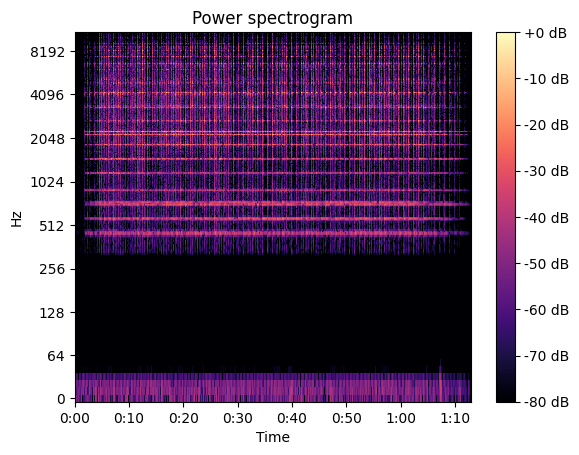

In [7]:
fig, ax = plt.subplots()
img = librosa.display.specshow(librosa.amplitude_to_db(D,
                                                       ref=np.max),
                               y_axis='log', x_axis='time', ax=ax)
ax.set_title('Power spectrogram')
fig.colorbar(img, ax=ax, format="%+2.0f dB")

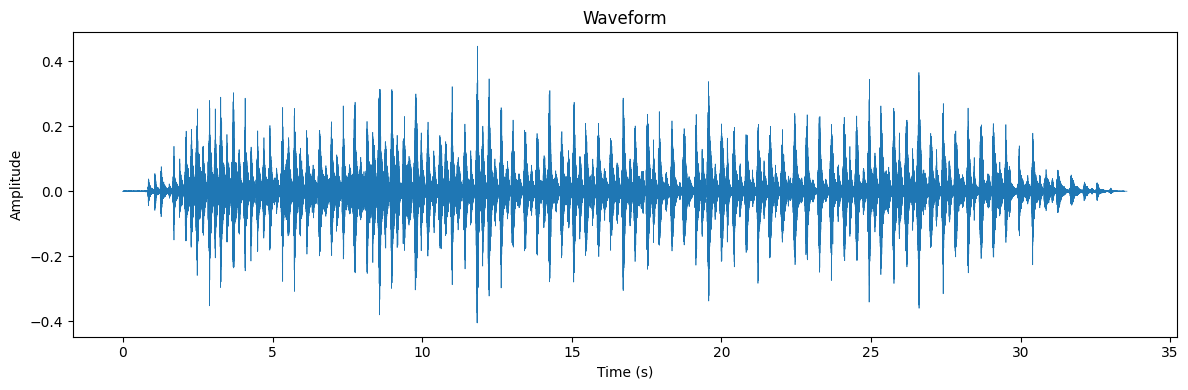

In [13]:
t = np.arange(len(y)) / sr          # or: np.linspace(0, len(y)/sr, len(y))

plt.figure(figsize=(12, 4))
plt.plot(t, y, linewidth=0.5)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Waveform")
plt.tight_layout()
plt.show()